# Heatwave Hazard Assessment — Kazakhstan
**CLIMAAX HEATWAVES (xclim) workflow adapted for Kazakhstan**

- Based on the CLIMAAX [Handbook](https://handbook.climaax.eu/) HEATWAVES workflow
- Uses ISIMIP3b bias-adjusted climate data (global) in place of EURO-CORDEX (EU only)
- The xclim package is used unchanged — only the input data and thresholds change

---
## Data Substitutions

| Original (CLIMAAX EU) | Kazakhstan replacement |
|---|---|
| EURO-CORDEX regional climate model, 12 km, EU domain only | ISIMIP3b bias-adjusted global data, 0.5° (~55 km) |
| Copernicus CDS API (`cdsapi`) | Direct HTTP download from `files.isimip.org` (no API key required) |
| Single GCM-RCM model combination | 1 GCM: GFDL-ESM4 (expandable to full 5-GCM ensemble) |
| RCP4.5 / RCP8.5 scenarios | SSP1-2.6 (ssp126) / SSP3-7.0 (ssp370) |
| Historical period 1971–2005 | Historical period 1971–2014 (ISIMIP3b historical run ends 2014) |
| Future period 2006–2100 | Future period 2015–2100 |
| Rotated-pole CORDEX CRS (reprojection required) | Standard WGS84 lat/lon — no reprojection needed |
| European temperature thresholds (25 °C Tasmax, 22 °C Tasmin) | **Kazhydromet-aligned thresholds: 35 °C Tasmax / 20 °C Tasmin** |
| `localtileserver` interactive map background | Static matplotlib context map |
| Single-model bar charts | 1-GCM output (as example) |

### Kazhydromet heatwave thresholds (official warning levels)

| Oblast group | Strong heat — Tasmax | Very strong heat — Tasmax |
|---|---|---|
| North KZ, Kostanay, Akmola, Pavlodar, West KZ, East KZ, Karaganda, South KZ, Aktobe | 35 °C | 40 °C |
| Mangystau, Zhambyl, Almaty Region | 38 °C | 43 °C |
| Kyzylorda | 40 °C | 45 °C |
| North KZ (Mangystau min) | −20 °C | −25 °C |

The default Tasmax threshold of **35 °C** applies to **Astana (Akmola Region)**.
Adjust `HWI_THRESH_TASMAX` and `HWF_THRESH_TASMAX` in Step 0 for other oblasts.

⚠️ **Tasmin threshold note**: Kazhydromet's official table specifies only Tasmax
thresholds. The Tasmin threshold of **20 °C** used for HWF and HWTL is drawn
from Central Asian climate health literature and represents a "warm night" condition
that prevents body recovery during a heatwave. It is **not an official Kazhydromet
value** and should be adjusted if a locally validated reference is available.

## Step 0: Configuration
*All user-adjustable parameters in one place.*

In [ ]:
from pathlib import Path

POINT_LAT     = 51.18      
POINT_LON     = 71.45      
LOCATION_NAME = "Astana"

CLIP_BBOX = [69.75, 49.75, 73.25, 52.75]

HWI_THRESH_TASMAX = '35 degC'
HWI_WINDOW        = 3        

HWF_THRESH_TASMAX = '35 degC'
HWF_THRESH_TASMIN = '20 degC'
HWF_WINDOW        = 3          

BASE_URL = (
    "https://files.isimip.org/ISIMIP3b/InputData/"
    "climate/atmosphere/bias-adjusted/global/daily"
)

MODEL_NAMES = [
    'gfdl-esm4'
]

MODEL_ENSEMBLE = {
    'gfdl-esm4':     'r1i1p1f1'
}
SCENARIOS = ['historical', 'ssp126', 'ssp370']
VARIABLES = ['tasmax', 'tasmin']

HISTORICAL_END = 2014   
FUTURE_START   = 2015
YEAR_START     = 1971
YEAR_END       = 2100

DECADES = {
    'historical': [
        (1971, 1980), (1981, 1990), (1991, 2000),
        (2001, 2010), (2011, 2014),
    ],
    'ssp126': [
        (2015, 2020), (2021, 2030), (2031, 2040), (2041, 2050),
        (2051, 2060), (2061, 2070), (2071, 2080), (2081, 2090),
        (2091, 2100),
    ],
    'ssp370': [
        (2015, 2020), (2021, 2030), (2031, 2040), (2041, 2050),
        (2051, 2060), (2061, 2070), (2071, 2080), (2081, 2090),
        (2091, 2100),
    ],
}

WORKFLOW_FOLDER = Path('Heatwave_hazard_XCLIM_KZ')
DATA_DIR        = WORKFLOW_FOLDER / 'data'
RESULTS_DIR     = WORKFLOW_FOLDER / 'results'

SHAPEFILE_PATH = Path(
    r"C:\Users\dauzo\Models\crabook-kazakhstan\crabook"
    r"\KAZ_BORDER_VERSION_1\LVL3\SHP_LVL3\KAZ_OSM_BORDER_LVL3.shp"
)
OBLAST_FIELD = "oblast_en"

## Step 1: Imports and Setup

In [ ]:
import warnings
import requests
import numpy as np
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xclim
import plotly.graph_objects as go

from ipyleaflet import Map, DrawControl, Marker, LayersControl
import ipywidgets as widgets
from IPython.display import display

warnings.filterwarnings('ignore')

In [13]:
WORKFLOW_FOLDER.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)
print(f"Data dir    : {DATA_DIR.resolve()}")
print(f"Results dir : {RESULTS_DIR.resolve()}")

Data dir    : C:\Users\dauzo\Models\crabook-kazakhstan\crabook\notebooks\workflows\HEATWAVES\01_Urban_heatwaves\Heatwave_hazard_XCLIM_KZ\data
Results dir : C:\Users\dauzo\Models\crabook-kazakhstan\crabook\notebooks\workflows\HEATWAVES\01_Urban_heatwaves\Heatwave_hazard_XCLIM_KZ\results


## Step 2: Download ISIMIP3b Data

Downloads `tasmax` and `tasmin` for all configured models × 3 scenarios × decade chunks.
Each global file (~1–2 GB) is immediately clipped to `CLIP_BBOX`, saved as a
compact NetCDF (a few MB), then the global file is deleted.
Already-clipped files are skipped (cache-first pattern).

In [ ]:
def build_url(model, scenario, var, start, end):
    ensemble  = MODEL_ENSEMBLE[model]
    model_dir = model.upper()              
    fname     = (
        f"{model}_{ensemble}_w5e5_{scenario}_{var}"
        f"_global_daily_{start}_{end}.nc"
    )
    return f"{BASE_URL}/{scenario}/{model_dir}/{fname}"


def process_chunk(model, scenario, var, start, end):
    from tqdm.auto import tqdm  

    clip_path = DATA_DIR / f"{model}_{scenario}_{var}_{start}_{end}_clip.nc"
    if clip_path.exists():
        tqdm.write(f"    Cached: {clip_path.name}") 
        return True

    url      = build_url(model, scenario, var, start, end)
    tmp_path = DATA_DIR / f"_tmp_{model}_{scenario}_{var}_{start}_{end}.nc"
    fname    = url.split('/')[-1]

    try:
        with requests.get(url, stream=True, timeout=300) as r:
            r.raise_for_status()
            total = int(r.headers.get('Content-Length', 0)) or None

            with (
                open(tmp_path, 'wb') as fout,
                tqdm(
                    total=total,
                    unit='B', unit_scale=True, unit_divisor=1024,
                    desc=f'    ↓ {fname}',
                    leave=False,       
                    dynamic_ncols=True,
                    position=1,         
                ) as pbar
            ):
                for chunk in r.iter_content(chunk_size=1 << 20):
                    fout.write(chunk)
                    pbar.update(len(chunk))

        with xr.open_dataset(tmp_path) as ds:
            ds_clip = ds.sortby('lat').sel(
                lat=slice(CLIP_BBOX[1], CLIP_BBOX[3]),
                lon=slice(CLIP_BBOX[0], CLIP_BBOX[2]),
            )
            ds_clip.load().to_netcdf(clip_path)

        import time
        for _ in range(5):
            try:
                tmp_path.unlink()
                break
            except PermissionError:
                time.sleep(1)
        else:
            tqdm.write(f"    ⚠ Could not delete temp file: {tmp_path.name}")

        tqdm.write(f"    ✓ Clipped & saved: {clip_path.name}")
        return True

    except Exception as exc:
        tqdm.write(f"    ✗ FAILED: {exc}")  
        if tmp_path.exists():
            tmp_path.unlink()
        return False

In [ ]:
from tqdm.auto import tqdm 

combos = [(m, s, v) for m in MODEL_NAMES for s in SCENARIOS for v in VARIABLES]

with tqdm(combos, desc='Overall progress', unit='combo') as outer: 
    for model, scenario, var in outer:
        key = f'{model}/{scenario}/{var}'
        outer.set_postfix_str(key, refresh=True)
        tqdm.write(f'\n{"─"*60}')   
        tqdm.write(f'  {key}')
        tqdm.write(f'{"─"*60}')
        results = [
            process_chunk(model, scenario, var, s, e)
            for s, e in DECADES[scenario]
        ]
        download_results[key] = results
        tqdm.write(f'  {sum(results)}/{len(results)} chunks complete')

print(f'\n{"="*60}')
print('DOWNLOAD SUMMARY')
print(f'{"="*60}')
all_ok = True
for key, chunks in download_results.items():
    n_ok   = sum(chunks)
    n_fail = len(chunks) - n_ok
    status = '✓ OK' if n_fail == 0 else f'✗ {n_fail} chunk(s) failed'
    print(f'  {key:<48s}  {n_ok}/{len(chunks)}  {status}')
    if n_fail:
        all_ok = False
msg = ('✓ All downloads complete.'
       if all_ok else
       '✗ Re-run this cell to retry failed chunks (cache-first).')
print(f'\n  {msg}')

Overall progress:   0%|          | 0/6 [00:00<?, ?combo/s]


────────────────────────────────────────────────────────────
  gfdl-esm4/historical/tasmax
────────────────────────────────────────────────────────────
    Cached: gfdl-esm4_historical_tasmax_1971_1980_clip.nc
    Cached: gfdl-esm4_historical_tasmax_1981_1990_clip.nc
    Cached: gfdl-esm4_historical_tasmax_1991_2000_clip.nc
    Cached: gfdl-esm4_historical_tasmax_2001_2010_clip.nc
    Cached: gfdl-esm4_historical_tasmax_2011_2014_clip.nc
  5/5 chunks complete

────────────────────────────────────────────────────────────
  gfdl-esm4/historical/tasmin
────────────────────────────────────────────────────────────
    Cached: gfdl-esm4_historical_tasmin_1971_1980_clip.nc
    Cached: gfdl-esm4_historical_tasmin_1981_1990_clip.nc
    Cached: gfdl-esm4_historical_tasmin_1991_2000_clip.nc
    Cached: gfdl-esm4_historical_tasmin_2001_2010_clip.nc
    Cached: gfdl-esm4_historical_tasmin_2011_2014_clip.nc
  5/5 chunks complete

────────────────────────────────────────────────────────────
  gfdl-e

    ↓ gfdl-esm4_r1i1p1f1_w5e5_ssp370_tasmin_global_daily_2061_2070.nc:   0%|          | 0.00/1.93G [00:00<?, ?…

    ✓ Clipped & saved: gfdl-esm4_ssp370_tasmin_2061_2070_clip.nc


    ↓ gfdl-esm4_r1i1p1f1_w5e5_ssp370_tasmin_global_daily_2071_2080.nc:   0%|          | 0.00/1.93G [00:00<?, ?…

    ✓ Clipped & saved: gfdl-esm4_ssp370_tasmin_2071_2080_clip.nc


    ↓ gfdl-esm4_r1i1p1f1_w5e5_ssp370_tasmin_global_daily_2081_2090.nc:   0%|          | 0.00/1.93G [00:00<?, ?…

    ✓ Clipped & saved: gfdl-esm4_ssp370_tasmin_2081_2090_clip.nc


    ↓ gfdl-esm4_r1i1p1f1_w5e5_ssp370_tasmin_global_daily_2091_2100.nc:   0%|          | 0.00/1.93G [00:00<?, ?…

    ✓ Clipped & saved: gfdl-esm4_ssp370_tasmin_2091_2100_clip.nc
  9/9 chunks complete

DOWNLOAD SUMMARY
  gfdl-esm4/historical/tasmax                       5/5  ✓ OK
  gfdl-esm4/historical/tasmin                       5/5  ✓ OK
  gfdl-esm4/ssp126/tasmax                           9/9  ✓ OK
  gfdl-esm4/ssp126/tasmin                           9/9  ✓ OK
  gfdl-esm4/ssp370/tasmax                           9/9  ✓ OK
  gfdl-esm4/ssp370/tasmin                           9/9  ✓ OK

  ✓ All downloads complete.


## Step 3: Load Data and Compute Heatwave Indices per Model

For each model × scenario combination:
1. Load and concatenate all decade files using the **robust manual-concat
   pattern** (avoids `open_mfdataset` hang issues with ISIMIP3b).
2. Convert K → °C; set required CF attributes for xclim (safety net).
3. Compute HWI, HWF, and HWTL on the full clipped 2D region.

Per-model results are cached to NetCDF so the cell can be re-run safely.

In [ ]:
def load_model_var(model, scenario, var):
    das = []
    for start, end in DECADES[scenario]:
        path = DATA_DIR / f"{model}_{scenario}_{var}_{start}_{end}_clip.nc"
        if not path.exists():
            raise FileNotFoundError(
                f"Missing clip file: {path}\nRe-run the download cell."
            )
        ds = xr.open_dataset(path).sortby('lat')
        das.append(ds[var])
    return xr.concat(das, dim='time').sortby('time')


def to_celsius(da):
    out = (da - 273.15).assign_attrs(da.attrs)
    out.attrs['units'] = 'degC'
    return out


def set_xclim_attrs(da, var):
    cell_methods = {
        'tasmax': 'time: maximum within days',
        'tasmin': 'time: minimum within days',
    }
    da.attrs.setdefault('standard_name', 'air_temperature')
    da.attrs.setdefault('long_name',     'Near-Surface Air Temperature')
    da.attrs.setdefault('cell_methods',  cell_methods[var])
    return da

In [ ]:
all_indices = {}  

for model in MODEL_NAMES:
    for scenario in SCENARIOS:
        cache_hwi  = DATA_DIR / f"{model}_{scenario}_hwi.nc"
        cache_hwf  = DATA_DIR / f"{model}_{scenario}_hwf.nc"
        cache_hwtl = DATA_DIR / f"{model}_{scenario}_hwtl.nc"

        if cache_hwi.exists() and cache_hwf.exists() and cache_hwtl.exists():
            print(f"  Cached indices : {model} / {scenario}")
            all_indices[(model, scenario, 'hwi')]  = xr.open_dataarray(cache_hwi)
            all_indices[(model, scenario, 'hwf')]  = xr.open_dataarray(cache_hwf)
            all_indices[(model, scenario, 'hwtl')] = xr.open_dataarray(cache_hwtl)
            continue

        print(f"  Computing      : {model} / {scenario}  ", end='', flush=True)

        tasmax = set_xclim_attrs(
            to_celsius(load_model_var(model, scenario, 'tasmax')), 'tasmax'
        )
        tasmin = set_xclim_attrs(
            to_celsius(load_model_var(model, scenario, 'tasmin')), 'tasmin'
        )

        hwi = xclim.indices.heat_wave_index(
            tasmax,
            thresh=HWI_THRESH_TASMAX,
            window=HWI_WINDOW,
            freq='YS',
            op='>',
            resample_before_rl=True,
        ).astype(float)

        hwf = xclim.indices.heat_wave_frequency(
            tasmin, tasmax,
            thresh_tasmin=HWF_THRESH_TASMIN,
            thresh_tasmax=HWF_THRESH_TASMAX,
            window=HWF_WINDOW,
            freq='YS',
            op='>',
            resample_before_rl=True,
        ).astype(float)

        hwtl = xclim.indices.heat_wave_total_length(
            tasmin, tasmax,
            thresh_tasmin=HWF_THRESH_TASMIN,
            thresh_tasmax=HWF_THRESH_TASMAX,
            window=HWF_WINDOW,
            freq='YS',
            op='>',
            resample_before_rl=True,
        ).astype(float)

        hwi.to_netcdf(cache_hwi)
        hwf.to_netcdf(cache_hwf)
        hwtl.to_netcdf(cache_hwtl)

        all_indices[(model, scenario, 'hwi')]  = hwi
        all_indices[(model, scenario, 'hwf')]  = hwf
        all_indices[(model, scenario, 'hwtl')] = hwtl
        print("✓")

print("\n  ✓ All indices computed.")

  Computing      : gfdl-esm4 / historical  ✓
  Computing      : gfdl-esm4 / ssp126  ✓
  Computing      : gfdl-esm4 / ssp370  ✓

  ✓ All indices computed.


## Step 4: Compute Ensemble Mean

Averages annual index values across all configured GCMs for each scenario using
`nanmean`, producing one 3D DataArray (time_annual, lat, lon) per scenario ×
index combination. With a single model this is equivalent to that model's output
directly; add more models to MODEL_NAMES to get a true ensemble mean.

Historical data is the same baseline for both future scenarios (each model
has a single historical run), so we compute one historical mean and
prepend it to each future scenario when plotting.

In [ ]:
def ensemble_mean(scenario, idx_name):
    arrays = [
        all_indices[(model, scenario, idx_name)]
        for model in MODEL_NAMES
    ]
    stacked = xr.concat(arrays, dim='model').assign_coords(model=MODEL_NAMES)
    return stacked.mean(dim='model', skipna=True)


ens_hist_hwi   = ensemble_mean('historical', 'hwi')
ens_hist_hwf   = ensemble_mean('historical', 'hwf')
ens_hist_hwtl  = ensemble_mean('historical', 'hwtl')

ens_ssp126_hwi   = ensemble_mean('ssp126', 'hwi')
ens_ssp126_hwf   = ensemble_mean('ssp126', 'hwf')
ens_ssp126_hwtl  = ensemble_mean('ssp126', 'hwtl')

ens_ssp370_hwi   = ensemble_mean('ssp370', 'hwi')
ens_ssp370_hwf   = ensemble_mean('ssp370', 'hwf')
ens_ssp370_hwtl  = ensemble_mean('ssp370', 'hwtl')

for name, da in [
    ('ens_ssp126_hwi',  ens_ssp126_hwi),
    ('ens_ssp126_hwf',  ens_ssp126_hwf),
    ('ens_ssp126_hwtl', ens_ssp126_hwtl),
    ('ens_ssp370_hwi',  ens_ssp370_hwi),
    ('ens_ssp370_hwf',  ens_ssp370_hwf),
    ('ens_ssp370_hwtl', ens_ssp370_hwtl),
]:
    da.to_netcdf(RESULTS_DIR / f'{name}.nc')

print(f"  ✓ Ensemble means saved to {RESULTS_DIR}")

  ✓ Ensemble means saved to Heatwave_hazard_XCLIM_KZ\results


## Step 5: Context Map

Static matplotlib figure showing the **30-year mean Heatwave Index (HWI)**
for SSP3-7.0 (2071–2100) over the Astana region, as a 2D spatial heatmap.

This replaces the `localtileserver`-based tile background from the original
notebook.  It helps orient the user before selecting a point in the
interactive `ipyleaflet` map below.

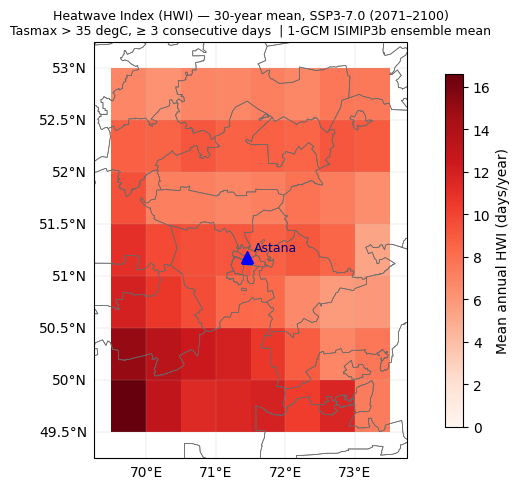

  Context map saved → Heatwave_hazard_XCLIM_KZ\results\context_map_HWI_ssp370_2071_2100.png


In [ ]:
kaz_gdf = gpd.read_file(SHAPEFILE_PATH)

hwi_mean_map = ens_ssp370_hwi.sel(time=slice('2071', '2100')).mean(dim='time')

fig, ax = plt.subplots(
    figsize=(8, 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

im = ax.pcolormesh(
    hwi_mean_map.lon.values,
    hwi_mean_map.lat.values,
    hwi_mean_map.values,
    cmap='Reds',
    transform=ccrs.PlateCarree(),
    vmin=0,
)
plt.colorbar(im, ax=ax, shrink=0.85, label='Mean annual HWI (days/year)')

kaz_gdf.plot(
    ax=ax, facecolor='none', edgecolor='dimgray',
    linewidth=0.5, transform=ccrs.PlateCarree(),
)

ax.plot(
    POINT_LON, POINT_LAT, 'b^', markersize=9,
    transform=ccrs.PlateCarree(), zorder=5,
)
ax.text(
    POINT_LON + 0.1, POINT_LAT + 0.06, LOCATION_NAME,
    transform=ccrs.PlateCarree(), fontsize=9, color='navy',
)

ax.set_extent(
    [CLIP_BBOX[0] - 0.5, CLIP_BBOX[2] + 0.5,
     CLIP_BBOX[1] - 0.5, CLIP_BBOX[3] + 0.5],
    crs=ccrs.PlateCarree(),
)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

ax.set_title(
    f'Heatwave Index (HWI) — 30-year mean, SSP3-7.0 (2071–2100)\n'
    f'Tasmax > {HWI_THRESH_TASMAX}, ≥ {HWI_WINDOW} consecutive days  '
    f'| {len(MODEL_NAMES)}-GCM ISIMIP3b ensemble mean',
    fontsize=9,
)
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / 'context_map_HWI_ssp370_2071_2100.png',
    dpi=150, bbox_inches='tight',
)
plt.show()
print(f"  Context map saved → {RESULTS_DIR / 'context_map_HWI_ssp370_2071_2100.png'}")

## Step 6: Interactive Point Selection

**This widget works in `.ipynb` mode** — convert with:
```
jupytext --to notebook heatwave_hazard_xclim_kz.py
```

The map is centred on Astana.  Click the **marker tool** (left panel) to
select any grid cell within the clipped region.  The following cells will
use those coordinates.

If you skip this cell (e.g., running as a plain `.py` script), the default
`POINT_LAT` / `POINT_LON` from Step 0 are used automatically.

In [ ]:
point_lat_list = [POINT_LAT]
point_lon_list = [POINT_LON]

m = Map(center=(POINT_LAT, POINT_LON), zoom=7)
m.add_control(LayersControl(position='topright'))

draw_control = DrawControl(
    marker={'shapeOptions': {'color': '#0033cc'}},
    rectangle={}, circlemarker={}, polyline={}, polygon={},
)
m.add_control(draw_control)

coord_label = widgets.Text(
    value=f'Default: lat={POINT_LAT}, lon={POINT_LON}  ({LOCATION_NAME})',
    disabled=True,
    layout=widgets.Layout(width='420px'),
)


def handle_draw(self, action, geo_json):
    if action == 'created' and geo_json['geometry']['type'] == 'Point':
        lon, lat = geo_json['geometry']['coordinates']
        coord_label.value = f'Selected: lat={lat:.4f}°N, lon={lon:.4f}°E'
        point_lat_list[0] = lat
        point_lon_list[0] = lon


draw_control.on_draw(handle_draw)
display(widgets.VBox([m, coord_label]))

After selecting a point above (or using the default Astana location), run
the next cell to extract the annual time series.

## Step 7: Extract Annual Time Series for the Selected Point

In [29]:
sel_lat = point_lat_list[0]
sel_lon = point_lon_list[0]
print(f"Analysis point : {sel_lat:.4f}°N, {sel_lon:.4f}°E")


def extract_point(da):
    """Select nearest ISIMIP3b grid cell; return 1-D numpy float array."""
    pt = da.sel(lat=sel_lat, lon=sel_lon, method='nearest')
    print(
        f"  → nearest grid cell: "
        f"lat={float(pt.lat):.2f}°N, lon={float(pt.lon):.2f}°E"
    )
    return pt.values.astype(float)


print("\nHistorical (1971–2014):")
hist_hwi_arr  = extract_point(ens_hist_hwi)
hist_hwf_arr  = extract_point(ens_hist_hwf)
hist_hwtl_arr = extract_point(ens_hist_hwtl)

print("\nSSP1-2.6 (2015–2100):")
ssp126_hwi_arr  = extract_point(ens_ssp126_hwi)
ssp126_hwf_arr  = extract_point(ens_ssp126_hwf)
ssp126_hwtl_arr = extract_point(ens_ssp126_hwtl)

print("\nSSP3-7.0 (2015–2100):")
ssp370_hwi_arr  = extract_point(ens_ssp370_hwi)
ssp370_hwf_arr  = extract_point(ens_ssp370_hwf)
ssp370_hwtl_arr = extract_point(ens_ssp370_hwtl)

# Concatenate historical + future for each scenario
full_hwi_126  = np.concatenate([hist_hwi_arr,  ssp126_hwi_arr])
full_hwf_126  = np.concatenate([hist_hwf_arr,  ssp126_hwf_arr])
full_hwtl_126 = np.concatenate([hist_hwtl_arr, ssp126_hwtl_arr])

full_hwi_370  = np.concatenate([hist_hwi_arr,  ssp370_hwi_arr])
full_hwf_370  = np.concatenate([hist_hwf_arr,  ssp370_hwf_arr])
full_hwtl_370 = np.concatenate([hist_hwtl_arr, ssp370_hwtl_arr])

# Year axis: 1971–2014 (historical) + 2015–2100 (future)
years_hist   = list(range(YEAR_START, HISTORICAL_END + 1))   # 44 values
years_future = list(range(FUTURE_START, YEAR_END + 1))        # 86 values
years_full   = years_hist + years_future                      # 130 values

print(f"\nTime axis   : {years_full[0]}–{years_full[-1]}  ({len(years_full)} years)")
print(f"Array check : HWI-126 length {len(full_hwi_126)} == years {len(years_full)} "
      f"→ {'✓' if len(full_hwi_126) == len(years_full) else '✗ MISMATCH'}")

Analysis point : 51.1800°N, 71.4500°E

Historical (1971–2014):
  → nearest grid cell: lat=51.25°N, lon=71.25°E
  → nearest grid cell: lat=51.25°N, lon=71.25°E
  → nearest grid cell: lat=51.25°N, lon=71.25°E

SSP1-2.6 (2015–2100):
  → nearest grid cell: lat=51.25°N, lon=71.25°E
  → nearest grid cell: lat=51.25°N, lon=71.25°E
  → nearest grid cell: lat=51.25°N, lon=71.25°E

SSP3-7.0 (2015–2100):
  → nearest grid cell: lat=51.25°N, lon=71.25°E
  → nearest grid cell: lat=51.25°N, lon=71.25°E
  → nearest grid cell: lat=51.25°N, lon=71.25°E

Time axis   : 1971–2100  (130 years)
Array check : HWI-126 length 130 == years 130 → ✓


## Step 8: Plot Results

Each plot shows the **5-GCM ensemble mean** annual value.
**Blue** = SSP1-2.6 (low emissions), **red** = SSP3-7.0 (high emissions).
Both scenarios share the same historical baseline (1971–2014).

In [ ]:
fig = go.Figure()
fig.add_trace(go.Bar(
    x=years_full, y=full_hwi_126,
    name='SSP1-2.6', marker_color='steelblue',
))
fig.add_trace(go.Bar(
    x=years_full, y=full_hwi_370,
    name='SSP3-7.0', marker_color='firebrick', opacity=0.6,
))
fig.add_annotation(
    xref='paper', yref='paper', x=1.0, y=-0.22, showarrow=False,
    text=(f'Source: ISIMIP3b bias-adjusted W5E5  |  '
        f'{len(MODEL_NAMES)}-GCM  '
        f'({", ".join(m.upper() for m in MODEL_NAMES)})'),
    font={'size': 9},
)
fig.update_layout(
    title={
        'text': (
            f'HEATWAVE INDEX (HWI)<br>'
            f'Annual days in heatwave events — Tasmax > {HWI_THRESH_TASMAX}, '
            f'≥ {HWI_WINDOW} consecutive days<br>'
            f'Location: {LOCATION_NAME}  '
            f'(lat {sel_lat:.2f}°N, lon {sel_lon:.2f}°E)'
        ),
        'x': 0.5, 'xanchor': 'center',
    },
    xaxis_title='Year',
    yaxis_title='Number of heatwave days',
    legend={'x': 0, 'y': 1, 'orientation': 'h'},
    width=1100, height=500,
)
fig.write_html(str(RESULTS_DIR / 'HWI_timeseries.html'))
fig.show()

In [ ]:
fig = go.Figure()
fig.add_trace(go.Bar(
    x=years_full, y=full_hwf_126,
    name='SSP1-2.6', marker_color='steelblue',
))
fig.add_trace(go.Bar(
    x=years_full, y=full_hwf_370,
    name='SSP3-7.0', marker_color='firebrick', opacity=0.6,
))
fig.add_annotation(
    xref='paper', yref='paper', x=1.0, y=-0.22, showarrow=False,
    text=(f'Source: ISIMIP3b bias-adjusted W5E5  |  '
          f'{len(MODEL_NAMES)}-GCM ensemble mean'),
    font={'size': 9},
)
fig.update_layout(
    title={
        'text': (
            f'HEATWAVE FREQUENCY (HWF)<br>'
            f'Annual heatwave events — Tasmax > {HWF_THRESH_TASMAX} AND '
            f'Tasmin > {HWF_THRESH_TASMIN}, ≥ {HWF_WINDOW} consecutive days<br>'
            f'Location: {LOCATION_NAME}  '
            f'(lat {sel_lat:.2f}°N, lon {sel_lon:.2f}°E)<br>'
            f'<sup>Tasmin threshold is indicative — see Data Substitutions table</sup>'
        ),
        'x': 0.5, 'xanchor': 'center',
    },
    xaxis_title='Year',
    yaxis_title='Number of heatwave events per year',
    legend={'x': 0, 'y': 1, 'orientation': 'h'},
    width=1100, height=500,
)
fig.write_html(str(RESULTS_DIR / 'HWF_timeseries.html'))
fig.show()

In [ ]:
fig = go.Figure()
fig.add_trace(go.Bar(
    x=years_full, y=full_hwtl_126,
    name='SSP1-2.6', marker_color='steelblue',
))
fig.add_trace(go.Bar(
    x=years_full, y=full_hwtl_370,
    name='SSP3-7.0', marker_color='firebrick', opacity=0.6,
))
fig.add_annotation(
    xref='paper', yref='paper', x=1.0, y=-0.22, showarrow=False,
    text=(f'Source: ISIMIP3b bias-adjusted W5E5  |  '
          f'{len(MODEL_NAMES)}-GCM ensemble mean'),
    font={'size': 9},
)
fig.update_layout(
    title={
        'text': (
            f'HEATWAVE TOTAL LENGTH (HWTL)<br>'
            f'Total annual heatwave days — Tasmax > {HWF_THRESH_TASMAX} AND '
            f'Tasmin > {HWF_THRESH_TASMIN}, ≥ {HWF_WINDOW} consecutive days<br>'
            f'Location: {LOCATION_NAME}  '
            f'(lat {sel_lat:.2f}°N, lon {sel_lon:.2f}°E)<br>'
            f'<sup>Tasmin threshold is indicative — see Data Substitutions table</sup>'
        ),
        'x': 0.5, 'xanchor': 'center',
    },
    xaxis_title='Year',
    yaxis_title='Total heatwave days per year',
    legend={'x': 0, 'y': 1, 'orientation': 'h'},
    width=1100, height=500,
)
fig.write_html(str(RESULTS_DIR / 'HWTL_timeseries.html'))
fig.show()

## Conclusions for the Kazakhstan Heatwave Hazard Assessment (xclim)

Three annual heatwave indicators were computed for Astana (and any user-selected
point within the clipped region) using ISIMIP3b bias-adjusted daily temperature
data under two climate scenarios:

- **HWI (Heatwave Index)**: total days per year spent inside heatwave events,
  defined solely by the Kazhydromet Tasmax threshold of 35 °C for ≥ 3 consecutive
  days.  This is the index most directly aligned with the official warning criteria.

- **HWF (Heatwave Frequency)**: count of distinct heatwave events per year,
  requiring both the day (Tasmax > 35 °C) and night (Tasmin > 20 °C) conditions
  to be met simultaneously for ≥ 3 consecutive days.  Because Kazakhstan has a
  strongly continental climate with large diurnal swings, HWF is typically lower
  than HWI — nights that cool below 20 °C break an ongoing event even when days
  remain extreme.

- **HWTL (Heatwave Total Length)**: sum of all qualifying days across all events
  in a year.  HWTL ≥ HWI when multiple separate events occur in the same year;
  they are equal when only one event occurs.

**Key caveats:**
- Results represent the nearest ISIMIP3b 0.5° grid cell (~55 km resolution).
  Urban heat-island effects in Astana are not captured.
- The bar charts show inter-annual variability of the ensemble mean; individual
  model years scatter considerably around this mean.
- For policy use, compute 20–30-year period averages (e.g. 2040–2060 vs
  1985–2005) rather than reading individual years as forecasts.
- The Tasmin threshold (20 °C) used in HWF and HWTL is indicative.
  If a locally validated night-temperature threshold becomes available from
  Kazhydromet or health authorities, update `HWF_THRESH_TASMIN` in Step 0.

## References

- Lange, S. (2019). Trend-preserving bias adjustment and statistical downscaling
  with ISIMIP3BASD. *Geosci. Model Dev.*, 12, 3055–3070.
- Bourgault et al. (2023). Xclim: xarray-based climate data analytics.
  *JOSS*, 8(85), 5415. DOI: 10.21105/joss.05415
- ISIMIP3b protocol: https://www.isimip.org/protocol/3b/
- Kazhydromet warning thresholds: official hazardous weather criteria table
  (сильная жара / очень сильная жара).

## Authors

- Original CLIMAAX workflow: Martin Kuban, Milan Kalas, Milica Aleksic
  (KAJO services); review by Natalia Aleksandrova (Deltares)